This notebook explores the pipeline of the mlp correction over lagrangian positions.

In [1]:
#We can import the configuration developed
import sys
import yaml
import pickle
import logging
import shutil
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import jax
import jax.numpy as jnp
import haiku as hk
import optax
import wandb

from jaxpm.kernels import fftk
from jaxpm.pm import get_delta, potential_kgrid_to_force_at_pos
from jaxpm.lagrangian import (
    get_axis_neighbor_indices,
    compute_deformation_features,
    compute_deformation_tensor,
    make_lagrangian_corrector,
)

logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO, format="%(levelname)s  %(message)s")

/cosmos_storage/home/diegovillalba/JaxPM/.venv/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


In [2]:
CONFIG_PATH="/cosmos_storage/home/diegovillalba/JaxPM/configs/lag_force_mlp.yaml"

In [3]:
with open(CONFIG_PATH) as f:
        cfg = yaml.safe_load(f)

exp_cfg   = SimpleNamespace(**cfg.get("experiment",  {}))
data_cfg  = SimpleNamespace(**cfg["data"])
model_cfg = SimpleNamespace(**cfg["model"])
train_cfg = SimpleNamespace(**cfg["training"])
wb_cfg    = cfg.get("wandb", {})

In [4]:
# coLAPSE THIS FOR BETTER READABILITY
out_dir = Path(getattr(exp_cfg, "output_dir", "runs/lag_force/TEST")) 
out_dir.mkdir(parents=True, exist_ok=True)
shutil.copy(CONFIG_PATH, out_dir / "config.yaml")

    # ── Config extraction ─────────────────────────────────────────────────────
mesh_lr       = int(data_cfg.mesh_lr)
mesh_hr       = int(data_cfg.mesh_hr)
box_size      = float(data_cfg.box_size)
n_part        = int(data_cfg.n_particles)
data_dir      = Path(data_cfg.data_dir)
snap_train    = int(data_cfg.snap_train)
sim_train     = int(getattr(data_cfg, "sim_id_train",  0))
sim_val       = int(getattr(data_cfg, "sim_id_val",    1))
snaps_val     = list(getattr(data_cfg, "snaps_val",    [snap_train]))

use_strain      = bool(getattr(model_cfg, "use_strain",      True))
use_invariants  = bool(getattr(model_cfg, "use_invariants",  False))
use_velocity    = bool(getattr(model_cfg, "use_velocity",    True))
output_mode     = getattr(model_cfg, "output_mode", "force")
output_dim      = 1 if output_mode == "potential" else 3

n_steps      = int(getattr(train_cfg, "n_steps",      500))
lr_val       = float(getattr(train_cfg, "lr",          3e-4))
weight_decay = float(getattr(train_cfg, "weight_decay", 1e-4))
warmup       = int(getattr(train_cfg, "warmup_steps",   50))
log_every    = int(getattr(train_cfg, "log_every",      25))
save_every   = int(getattr(train_cfg, "save_every",    100))
seed         = int(getattr(train_cfg, "seed",            0))

In [5]:
# Create the model
lag_model = make_lagrangian_corrector(
        hidden_dim = int(getattr(model_cfg, "hidden_dim", 64)),
        n_layers   = int(getattr(model_cfg, "n_layers",   3)),
        output_dim = output_dim,
    )

In [6]:
neighbor_idx = get_axis_neighbor_indices(n_part) 

INFO:2026-04-30 03:53:24,393:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO  Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [7]:
#CODE FOR LOADING THE SNAPSHOT
def load_snapshot(
    data_dir: Path,
    sim_id: int,
    snap_idx: int,
    mesh_lr: int,
    mesh_hr: int,
    box_size: float,
    load_hr: bool = True,
) -> tuple:
    """
    Load one snapshot; returns positions and velocities in mesh_lr units.

    Returns (pos_lr, vel_lr, pos_hr_or_None, a)
    """
    scale = float(mesh_lr) / float(box_size)

    pos_lr = np.load(data_dir / f"pos_m{mesh_lr}_s{sim_id}.npy")[snap_idx]
    vel_lr = np.load(data_dir / f"vel_m{mesh_lr}_s{sim_id}.npy")[snap_idx]
    avals  = np.load(data_dir / "scale_factors.npy")
    a_val  = float(avals[snap_idx])

    pos_lr = jnp.array(pos_lr * scale, dtype=jnp.float32)
    vel_lr = jnp.array(vel_lr * scale, dtype=jnp.float32)

    pos_hr = None
    if load_hr:
        try:
            print(f"pos_m{mesh_hr}_s{sim_id}.npy")
            pos_hr_raw = np.load(data_dir / f"pos_m{mesh_hr}_s{sim_id}.npy")[snap_idx]
            pos_hr = jnp.array(pos_hr_raw * scale, dtype=jnp.float32)
        except FileNotFoundError:
            logger.warning(f"HR data not found for sim {sim_id}, using LR particles at HR resolution")

    return pos_lr, vel_lr, pos_hr, a_val

In [8]:
pos_lr_t, vel_lr_t, pos_hr_t, a_train = load_snapshot(
        data_dir, sim_train, snap_train, mesh_lr, mesh_hr, box_size
    )

pos_m512_s0.npy


In [9]:
pos_hr_t.shape

(2097152, 3)

Text(0.5, 1.0, 'HR')

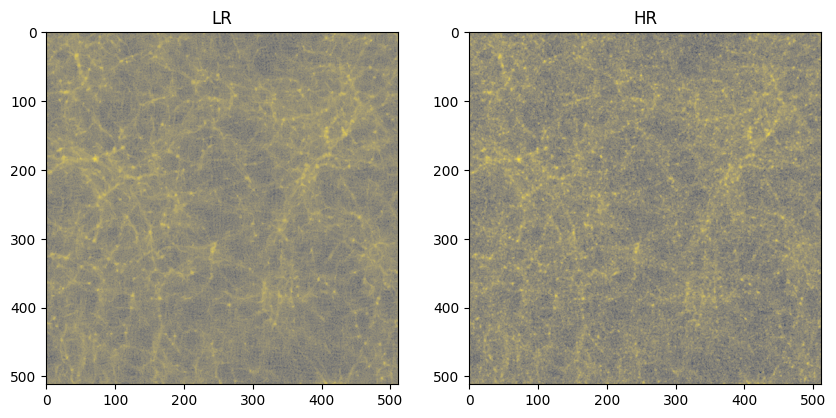

In [13]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
mesh_plot = 512
cmap = "cividis"

delta_hr = get_delta(pos_hr_t * 4, (mesh_plot, mesh_plot, mesh_plot))
norm = LogNorm(
    vmin=delta_hr.sum(axis=0).min(),
    vmax=delta_hr.sum(axis=0).max(),
)
delta_lr = get_delta(pos_lr_t* 4, (mesh_plot, mesh_plot, mesh_plot))


fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
ax[0].imshow((delta_lr[:, :, :]).sum(axis=0), norm=norm, cmap=cmap)

ax[1].imshow((delta_hr[:, :, :]).sum(axis=0), norm=norm, cmap=cmap)

ax[0].set_title("LR")
ax[1].set_title("HR")

In [14]:
def snapshot_features(pos_t, neighbor_idx, mesh_lr, use_strain, use_invariants):
    """Compute (feats [N, D], det_D [N]) for a single snapshot."""
    feats = jax.jit(
        compute_deformation_features, static_argnums=(2, 3, 4)
    )(pos_t, neighbor_idx, mesh_lr, use_strain, use_invariants)

    neg_idx = neighbor_idx[:, [1, 3, 5]]
    _, det_D = jax.jit(
        lambda p: compute_deformation_tensor(p, neg_idx, mesh_lr)
    )(pos_t)
    det_D = np.asarray(jax.device_get(det_D))
    return feats, det_D

In [15]:
feats_train, det_D_train = snapshot_features(
        pos_lr_t, neighbor_idx, mesh_lr, use_strain, use_invariants
    )

In [19]:
from pm2nbody.train_lag_force import compute_force_pair


_force_pair_lr_only = jax.jit(
        lambda pos: compute_force_pair(pos, mesh_lr, mesh_hr, None)
    )
_force_pair_with_hr = jax.jit(
        lambda pos, pos_hr: compute_force_pair(pos, mesh_lr, mesh_hr, pos_hr)
    )
def _get_force_pair(pos, pos_hr):
        """Dispatch to the right jit-compiled variant depending on HR availability."""
        return _force_pair_lr_only(pos) if pos_hr is None else _force_pair_with_hr(pos, pos_hr)

In [20]:
sc_frac_train = float(np.mean(det_D_train < 0))
strain_mag    = float(jnp.mean(jnp.sqrt(jnp.sum(feats_train[:, :9] ** 2, axis=-1))))
logger.info(f"  shell-crossing fraction: {sc_frac_train:.3%}   ||E||_F mean: {strain_mag:.4f}")

    # Force pair
logger.info("Computing force pairs …")
f_pm_tr, f_ref_tr, delta_f_tr = _get_force_pair(pos_lr_t, pos_hr_t)

INFO    shell-crossing fraction: 83.884%   ||E||_F mean: 2.3498
INFO  Computing force pairs …


In [ ]:
# ── Parámetros del sub-volumen ────────────────────────────────────────────────
SV_CENTER  = np.array([64.0, 64.0, 64.0])   # centro en unidades de malla
SV_HALF    = 12.0                            # semi-arista del cubo (mesh cells)
N_CENTRAL  = 30                              # partículas centrales a destacar

DIR_LABELS = ["+x", "−x", "+y", "−y", "+z", "−z"]
DIR_COLORS = ["#E63946", "#FF8C00", "#2EC4B6", "#118AB2", "#8338EC", "#FB5607"]

# ── Partículas en el sub-volumen (posición actual) ────────────────────────────
pos_np    = np.asarray(jax.device_get(pos_lr_t)) % mesh_lr   # [N, 3]
nbr_np    = np.asarray(neighbor_idx)                          # [N, 6]

in_sv = np.all(np.abs(pos_np - SV_CENTER) < SV_HALF, axis=1)
sv_idx = np.where(in_sv)[0]

# Elegir N_CENTRAL partículas al azar dentro del sub-volumen
rng_vis = np.random.default_rng(42)
sel_idx = rng_vis.choice(sv_idx, size=min(N_CENTRAL, len(sv_idx)), replace=False)

# ── Figura ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 10))
ax  = fig.add_subplot(111, projection="3d")
ax.set_facecolor("#0D1117")
fig.patch.set_facecolor("#0D1117")

# Todas las partículas del sub-volumen en gris tenue (contexto)
ax.scatter(*pos_np[sv_idx].T, s=0.8, c="#444455", alpha=0.25, rasterized=True)

# Vecinos de cada partícula central, coloreados por dirección
for k, (label, color) in enumerate(zip(DIR_LABELS, DIR_COLORS)):
    nbr_global = nbr_np[sel_idx, k]          # [N_CENTRAL] índices globales
    nbr_pos    = pos_np[nbr_global]           # posición ACTUAL del vecino [N_CENTRAL, 3]
    ax.scatter(*nbr_pos.T, s=28, c=color, alpha=0.85, label=f"nbr {label}",
               edgecolors="none", zorder=4)

# Líneas central → vecino (imagen mínima periódica)
for ci in sel_idx:
    cpos = pos_np[ci]
    for k, color in enumerate(DIR_COLORS):
        npos = pos_np[nbr_np[ci, k]]
        d    = npos - cpos
        d   -= mesh_lr * np.round(d / mesh_lr)   # periodic wrap
        ax.plot(
            [cpos[0], cpos[0] + d[0]],
            [cpos[1], cpos[1] + d[1]],
            [cpos[2], cpos[2] + d[2]],
            c=color, lw=0.6, alpha=0.20
        )

# Partículas centrales encima de todo
ax.scatter(*pos_np[sel_idx].T, s=55, c="white", edgecolors="#CCCCCC",
           linewidths=0.4, zorder=6, label="central")

# Caja del sub-volumen
lo, hi = SV_CENTER - SV_HALF, SV_CENTER + SV_HALF
for xs in [(lo[0], hi[0])]:
    for ys in [(lo[1], hi[1])]:
        ax.plot([xs[0], xs[0]], [ys[0], ys[0]], [lo[2], hi[2]], c="#555577", lw=0.5)
        ax.plot([xs[0], xs[0]], [ys[1], ys[1]], [lo[2], hi[2]], c="#555577", lw=0.5)
for zs in [(lo[2], hi[2])]:
    ax.plot([lo[0], hi[0]], [lo[1], lo[1]], [zs[0], zs[0]], c="#555577", lw=0.5)
    ax.plot([lo[0], hi[0]], [hi[1], hi[1]], [zs[0], zs[0]], c="#555577", lw=0.5)

ax.set_xlabel("x  [mesh cells]", color="white", labelpad=6)
ax.set_ylabel("y  [mesh cells]", color="white", labelpad=6)
ax.set_zlabel("z  [mesh cells]", color="white", labelpad=6)
ax.tick_params(colors="white", labelsize=7)
for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
    pane.fill = False
    pane.set_edgecolor("#222233")
ax.grid(False)

leg = ax.legend(loc="upper left", fontsize=8, framealpha=0.15,
                labelcolor="white", markerscale=1.6)
leg.get_frame().set_facecolor("#1A1A2E")

ax.set_title(
    f"Vecinos Lagrangianos  |  a = {a_train:.3f}  |  "
    f"{len(sel_idx)} partículas centrales  ·  {len(sv_idx):,} en sub-volumen",
    color="white", fontsize=11, pad=12
)
plt.tight_layout()
plt.show()

# Diagnóstico: ¿cuántos vecinos están FUERA del sub-volumen?
nbrs_outside = 0
for ci in sel_idx:
    for k in range(6):
        ni = nbr_np[ci, k]
        if not in_sv[ni]:
            nbrs_outside += 1
print(f"Vecinos fuera del sub-volumen euleriano: "
      f"{nbrs_outside} / {len(sel_idx)*6}  "
      f"({nbrs_outside/(len(sel_idx)*6):.1%})  "
      f"← separación lagrangiana→euleriana")